# Craig Transform

Transforming $G_{UV},\,G_{NE}$ to $g_{D}$

The Craig transform provides functionality to generate gravity from differential curvatures.

This tutorial demonstrates its use on publicly available data (resources.vic.gov.au) from the Fosterville Falcon airborne gravity gradiometer survey.

The Craig transform calculates any or all components of the gravity gradient and the gravity acceleration from measured differential curvature gradients. The transform is performed in the wavenumber domain using the Fourier transform. The gravity gradient tensor is derived from:

$$\mathcal{F}\left(\Gamma\right)=\frac{2}{\left(k_{N}+i k_{E}\right)^{2}}\begin{bmatrix}k_N^2 & k_N k_E & ik_N k \\ & k_E^2 & i k_E k \\  &  & -k^2 \\\end{bmatrix}\mathcal{F}\left(\Gamma_{UV}+i \Gamma_{NE}\right)$$

and the gravitational acceleration vector from

$$\mathcal{F}\left(\mathbf{g}\right)=\frac{2}{\left(k_{N}+i k_{E}\right)^{2}}\begin{bmatrix}-ik_N & -ik_E & -k \end{bmatrix}\mathcal{F}\left(\Gamma_{UV}+i \Gamma_{NE}\right)$$

where $k=\sqrt{k_N^2+k_E^2}$ is the radial wavenumber on the horizontal plane.

The implementation here only derives the vertical gravitational acceleration:

$$\mathcal{F}\left(g_D\right)=\frac{-2k}{\left(k_{N}+i k_{E}\right)^{2}}\mathcal{F}\left(\Gamma_{UV}+i \Gamma_{NE}\right)$$

The method proceeds in several steps.

1. The measured differential curvature ($\Gamma_{UV}$ and $\Gamma_{NE}$) data are separately gridded. This is done by minimum curvature with a default cell size 1/4 of the line spacing although the user may select their own value. Grid cells further than 3 cells from a located data value are marked "missing".

1. Each grid is padded to extend the size of the grid in all four directions, and to fill any missing data. The padding may be done by sampling from a regional gravity grid, by filling with the mean value, or by a constant value. Regional gravity padding provides the best result. The regional grid is transformed by the reverse Craig transform to the differential curvature components and interpolated onto the locations of the measured differential curvature grids.

1. The padded data are transformed to $g_D$ using the bottom equation above. Then the cells that were padded for the transform are marked as missing since they did not originally have a measured value. The grid is then trimmed to the smallest rectangle possible without removing good data.

1. This grid is sampled back to the `whizzFile` from which the differential curvature data originated.

Note that the method treats all data as though it is located on a horizontal plane. This is a good approximation for many airborne gravity gradient surveys but will give inaccurate results for surveys draped to follow rugged terrain.

## Fosterville Example

The Fosterville data were downloaded from Resources Victoria. The located data were in ASEG-GDF2 format and these were written to `whizzFile` in HDF5 format. Most channels were omitted to reduce the data volume. It is this minimalist data set that is used here. For no particular reason, this example uses the free-air data.

___
Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path
import pegasusQC as qc

data_root = r'./FostervilleData/'
FostervilleHDF_file = Path(data_root + r'Foster_craig.hdf5')
regional_fa_ers = Path(data_root + r'Gravmap2019-grid-grv_fa.ers')

In [2]:
if not FostervilleHDF_file.exists():
    print("Ask Mark for help!!!")

In [3]:
# Find the channel names for the free-air Gne and Guv data
qc.reportChannels(FostervilleHDF_file)

Whizz Version 1.0

8 channels:


8 channels:
['Elevation_GNSS_GRS80', 'Falc_A_NE_0p00_0p18Hz_MeanLev',
'Falc_A_UV_0p00_0p18Hz_MeanLev', 'Falc_gD_0p00_0p18HzLP_ESD300m_SDS',
'GNSS_Easting_WGS84UTM55', 'GNSS_Northing_WGS84UTM55',
'Smooth_Drape_Surface_EGM96', 'Time_SSM_UTC1980']


Reading located data from whizz file.
206 lines; total number of fids in whizz file = 366670.
    Falc_A_NE_0p00_0p18Hz_MeanLev: min = -51.8, max = 39.8, mean = 0.0262.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_UV_0p00_0p18Hz_MeanLev: min = -41.5, max = 67.7, mean = -0.312.


Gridding data with cell size = 50.0.

Reading in the regional data for padding.

Interpolating the local curvature gradients to grids.
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_NE_0p00_0p18Hz_MeanLev).
 Falc_A_NE_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
3 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_UV_0p00_0p18Hz_MeanLev).
 Falc_A_UV_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
3 poin

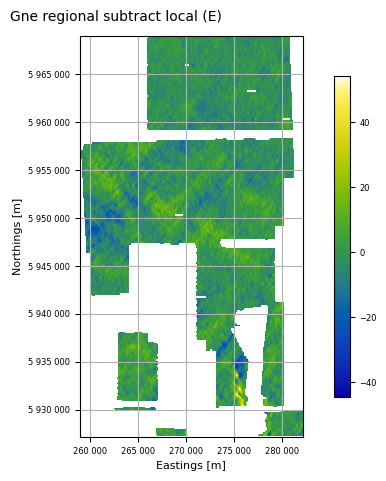


 Grid stats Guv regional subtract local
RMS of result = 4.97
mean of result = 0.04
min of result = -65.85
max of result = 36.75
Array shape = (1349, 978)


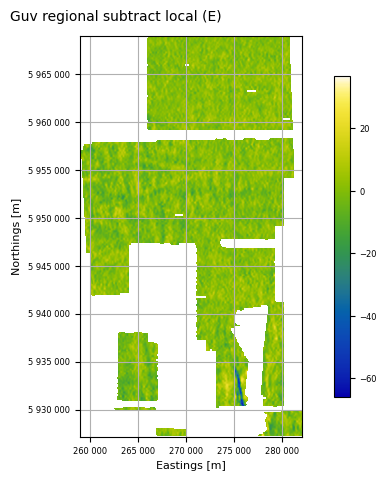


Transforming the local curvature gradient grids to gravity.
Wavenumber resolution = 2.04e-05
Equivalent wavelength = 4.89e+04 m.
RMS of result = 6.13 um/s/s
mean of result = 0.00 um/s/s
min of result = -14.90 um/s/s
max of result = 27.72 um/s/s
Array shape = (836, 465)


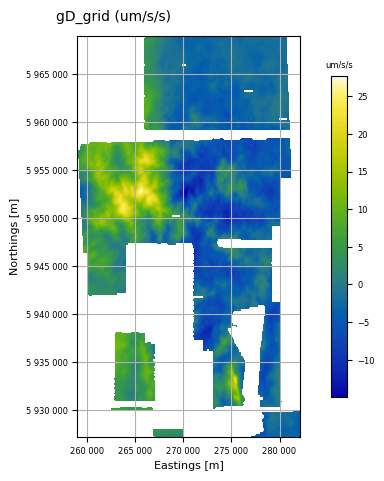

RMS of result = 4.65 um/s/s
mean of result = -1.18 um/s/s
min of result = -12.15 um/s/s
max of result = 13.84 um/s/s
Array shape = (836, 465)


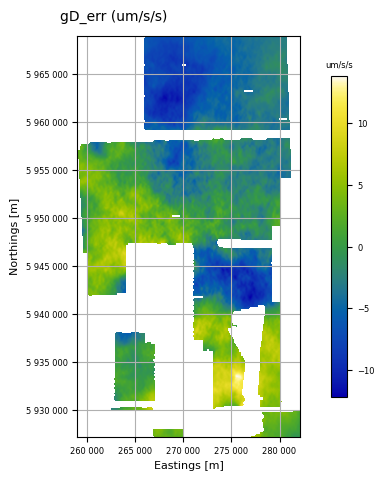

In [4]:
gD_grid = qc.craig_transform(
    whizzFile=FostervilleHDF_file, 
    gne_chan='Falc_A_NE_0p00_0p18Hz_MeanLev', 
    guv_chan='Falc_A_UV_0p00_0p18Hz_MeanLev',
    gd_chan=None,
    result_units='um/s/s',
    mask_polygon=None,
    pad_cells=256, 
    padding_mode="regional", 
    regional_grid_file=regional_fa_ers,
    regional_grav_units='gu',
)

## Telfer Example

These data were downloaded from the Geological Survey of Western Australia at https://geodownloads.dmp.wa.gov.au/downloads/geophysics/71234/.

In [5]:
from pathlib import Path
import pegasusQC as qc

data_root = r'./TelferData/'
TelferHDF_file = Path(data_root + r'Telfer_craig.hdf5')

regional_fa_ers = Path(data_root + r'Gravmap2019-grid-grv_dtgir.ers')

true_gd_ers = Path(data_root + r'2131_1_Fourier_gD_2p2_conformed_final.ers')

In [6]:
if not TelferHDF_file.exists():
    print("Ask Mark for help!!!")
    # %run ./Prepare_EastVicData.ipynb

In [7]:
# Find the channel names for the free-air Gne and Guv data
qc.reportChannels(TelferHDF_file)

Whizz Version 1.0

11 channels:


11 channels:
['ALTITUDE_Ellipsoid', 'A_NE_0', 'A_NE_2p67', 'A_UV_0', 'A_UV_2p67',
'DRAPESURFACE_FOURIER', 'EASTING', 'FIDUCIAL', 'NORTHING',
'gD_FOURIER_0', 'gD_FOURIER_2p67']


Reading located data from whizz file.
269 lines; total number of fids in whizz file = 1122946.
    A_NE_2p67: min = -161, max = 40.1, mean = -22.3.

269 lines; total number of fids in whizz file = 1122946.
    A_UV_2p67: min = -96.2, max = 52.7, mean = -28.9.


Reading in the regional data for padding.

Interpolating the local curvature gradients to grids.
Processing (x, y, z) = (EASTING, NORTHING, A_NE_2p67).
 A_NE_2p67 in eotvos.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
5 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (EASTING, NORTHING, A_UV_2p67).
 A_UV_2p67 in eotvos.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
5 point(s) excluded.
Creating minimum curvature grid...
Finished!

Padding the local curvature gradient grids.
Wavenumber resolution = 3.36e-06
Equivalent wavelength = 2.98e+05 m.

Grid Statistics
  Gne regional
RMS of result = 1.93 eotvos
mea

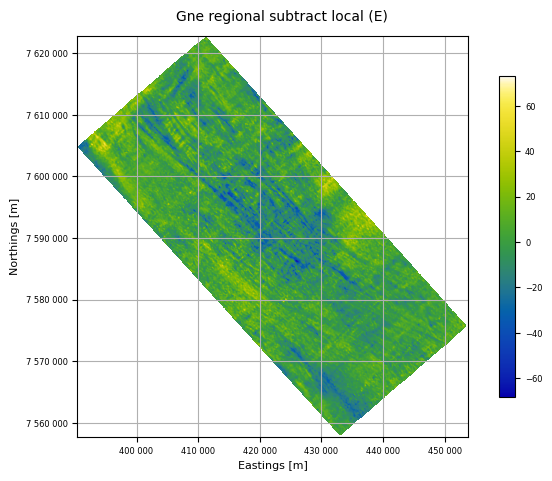


 Grid stats Guv regional subtract local
RMS of result = 8.41
mean of result = 1.02
min of result = -69.87
max of result = 60.37
Array shape = (1328, 1308)


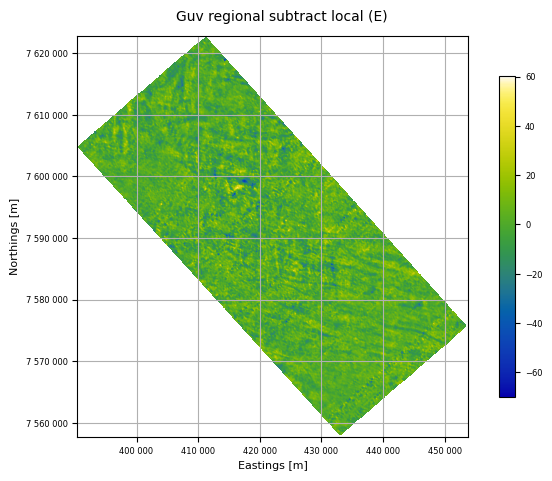


Transforming the local curvature gradient grids to gravity.
Wavenumber resolution = 9.56e-06
Equivalent wavelength = 1.05e+05 m.
RMS of result = 33.83 um/s/s
mean of result = -4.35 um/s/s
min of result = -124.72 um/s/s
max of result = 76.41 um/s/s
Array shape = (815, 794)


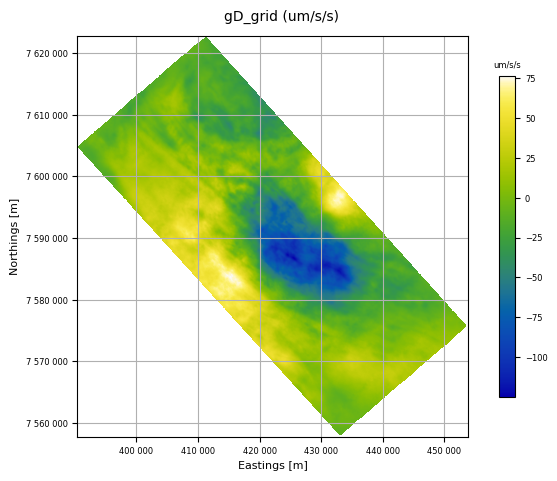

RMS of result = 17.80 um/s/s
mean of result = 13.70 um/s/s
min of result = -26.89 um/s/s
max of result = 64.96 um/s/s
Array shape = (815, 794)


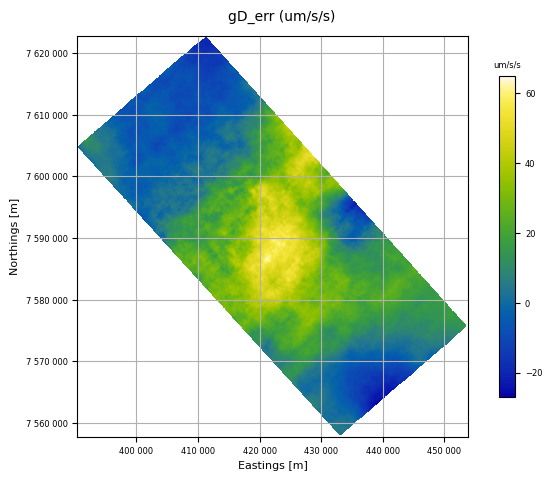

In [8]:
gD_grid = qc.craig_transform(
    whizzFile=TelferHDF_file,
    gne_chan='A_NE_2p67',
    guv_chan='A_UV_2p67',
    gd_chan=None,
    cell_size=80.0,
    result_units='um/s/s',
    mask_polygon=None,
    pad_cells=256,
    padding_mode="regional",
    regional_grid_file=regional_fa_ers,
    regional_grav_units='um/s/s'
)

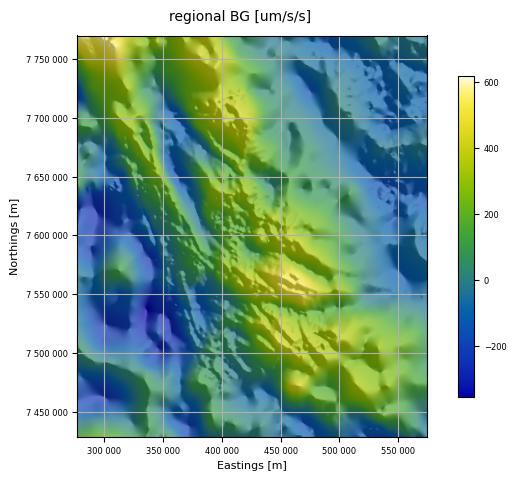

In [9]:
reg_bg, _ = qc.gridfile_to_xa(regional_fa_ers)
qc.xdImage(reg_bg, 'regional BG [um/s/s]')

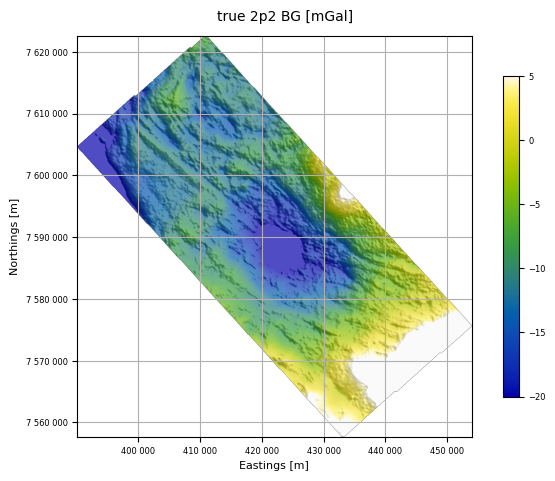

In [10]:
true_bg, _ = qc.gridfile_to_xa(true_gd_ers)
qc.xdImage(true_bg, 'true 2p2 BG [mGal]', minClip=-20, maxClip=5)

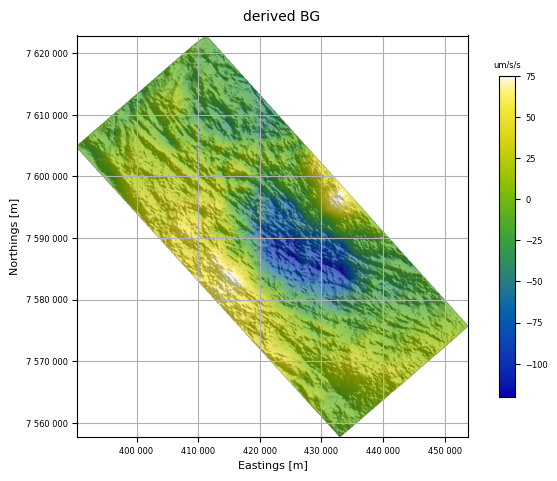

In [11]:
qc.xdImage(gD_grid, 'derived BG', hs=True, minClip=-120, maxClip=75)